In [22]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam (2).csv


In [23]:

import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [24]:
import pandas as pd

dataset = pd.read_csv("spam.csv", encoding="latin-1")
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [25]:
dataset = dataset[['v1', 'v2']]

dataset.columns = ['label', 'message']

dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [26]:
if 'v1' in dataset.columns and 'v2' in dataset.columns:
    dataset = dataset.rename(columns={'v1': 'Category', 'v2': 'Message'})

dataset.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
dataset = dataset.rename(columns={'v1': 'Category', 'v2': 'Message'})

dataset.head()
print(dataset.columns)



Index(['label', 'message'], dtype='object')


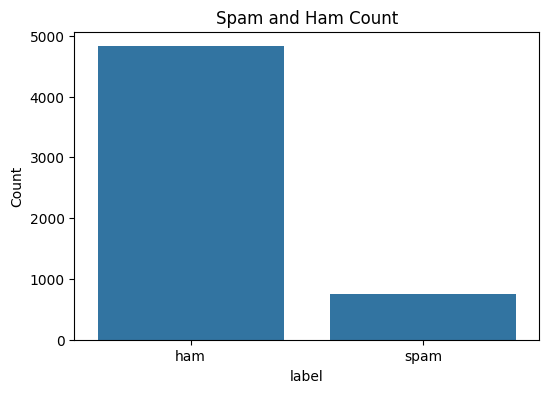

In [28]:
X = dataset['label'].values
y = dataset['message'].values
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=dataset)
plt.title("Spam and Ham Count")
plt.xlabel("label")
plt.ylabel("Count")
plt.savefig("exercise3a.png")
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0)

In [30]:
cv = CountVectorizer()
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

In [21]:

classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

In [32]:
from sklearn.svm import SVC

classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

print("Accuracy:", classifier.score(X_test, y_test))



Accuracy: 0.003587443946188341
